# QSAR Classical Classification Benchmark

Binary toxicity (log_LC50 < 1): 10+ models, selects best 3 by AUC-ROC.

## 0. Setup

In [11]:
import pandas as pd, numpy as np, warnings, pickle, os
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator, Descriptors
from rdkit.ML.Descriptors import MoleculeDescriptors
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, roc_auc_score, precision_score,
                             recall_score, f1_score, confusion_matrix)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               ExtraTreesClassifier, AdaBoostClassifier)
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
import xgboost as xgb
import lightgbm as lgb
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')
np.random.seed(42)

## 1. Load + binarize

In [2]:
df = pd.read_csv('data/curated_data_rdkit_Imane.csv')
df.rename(columns={'logC50':'log_LC50','SMILES_curated':'SMILES'}, inplace=True)
meta = df['CAS'].astype(str).str.contains('Meta', na=False)
df = df[~meta].reset_index(drop=True)
df['mol'] = df['SMILES'].apply(lambda s: Chem.MolFromSmiles(s) if s else None)
df = df.dropna(subset=['mol']).reset_index(drop=True)
df['toxic'] = (df['log_LC50'] < 1.0).astype(int)
pos = df['toxic'].sum(); neg = len(df) - pos
print(f'Molecules: {len(df)} | Toxic: {pos} ({pos/len(df)*100:.1f}%) | Non-toxic: {neg} ({neg/len(df)*100:.1f}%)')

Molecules: 1559 | Toxic: 704 (45.2%) | Non-toxic: 855 (54.8%)


Class distribution:
Non-toxic : 855 (54.8%)
Toxic     : 704 (45.2%)


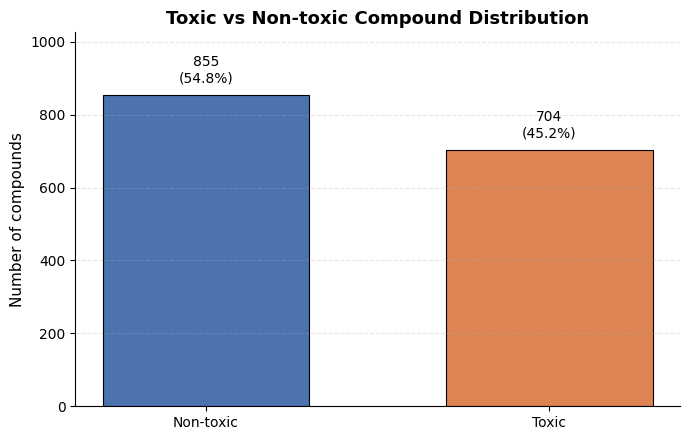

In [20]:
# Class distribution with a cleaner plot
dist = df['toxic'].value_counts().sort_index()
labels = {0: 'Non-toxic', 1: 'Toxic'}
colors = ['#4C72B0', '#DD8452']

total = len(df)
print('Class distribution:')
for cls, count in dist.items():
    pct = count / total * 100
    print(f"{labels[cls]:<10s}: {count} ({pct:.1f}%)")

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(
    [labels[i] for i in dist.index],
    dist.values,
    color=colors,
    edgecolor='black',
    linewidth=0.8,
    width=0.6
)

ax.set_title('Toxic vs Non-toxic Compound Distribution', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of compounds', fontsize=11)
ax.set_ylim(0, max(dist.values) * 1.2)
ax.grid(axis='y', linestyle='--', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for bar, count in zip(bars, dist.values):
    pct = count / total * 100
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(dist.values) * 0.03,
        f'{count}\n({pct:.1f}%)',
        ha='center',
        va='bottom',
        fontsize=10
    )

plt.tight_layout()
plt.show()

## 2. Feature engineering

In [6]:
gen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
fps = np.array([gen.GetFingerprint(m) for m in df['mol']])
desc_names = [d[0] for d in Descriptors._descList]
calculator = MoleculeDescriptors.MolecularDescriptorCalculator(desc_names)
descs = np.array([list(calculator.CalcDescriptors(m)) for m in df['mol']])
X_raw = np.hstack([fps, descs])
y = df['toxic'].values
print(f'Features: {X_raw.shape[1]} (2048 Morgan + {len(desc_names)} RDKit descs)')
sel = VarianceThreshold(0.01)
X = sel.fit_transform(X_raw)
print(f'After variance filter: {X.shape[1]}')
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)
print(f'Train: {X_train_s.shape[0]} | Test: {X_test_s.shape[0]}')

Features: 2265 (2048 Morgan + 217 RDKit descs)
After variance filter: 602
Train: 1247 | Test: 312


## 3. Benchmark models

In [12]:
models = {
    'LogisticRegression': LogisticRegression(max_iter=2000, random_state=42, n_jobs=-1),
    'RandomForest': RandomForestClassifier(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1),
    'XGBoost': xgb.XGBClassifier(n_estimators=300, max_depth=6, learning_rate=0.05, random_state=42, n_jobs=-1),
    'LightGBM': lgb.LGBMClassifier(n_estimators=300, max_depth=8, learning_rate=0.05, random_state=42, n_jobs=-1, verbose=-1),
    'SVM': SVC(kernel='rbf', C=1.0, gamma='scale', probability=True, random_state=42),
    'GradientBoosting': GradientBoostingClassifier(n_estimators=200, max_depth=4, learning_rate=0.05, random_state=42),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=300, max_depth=20, random_state=42, n_jobs=-1),
    'AdaBoost': AdaBoostClassifier(n_estimators=200, learning_rate=0.05, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=15, weights='distance', n_jobs=-1),
    'DecisionTree': DecisionTreeClassifier(max_depth=10, random_state=42),
    'GaussianNB': GaussianNB(),
}
print(f'Models: {list(models.keys())}')

Models: ['LogisticRegression', 'RandomForest', 'XGBoost', 'LightGBM', 'SVM', 'GradientBoosting', 'ExtraTrees', 'AdaBoost', 'KNN', 'DecisionTree', 'GaussianNB']


In [13]:
results = []
for name, m in models.items():
    use_s = name in ['LogisticRegression', 'SVM', 'KNN', 'GaussianNB']
    X_tr, X_te = (X_train_s, X_test_s) if use_s else (X_train, X_test)
    m.fit(X_tr, y_train)
    if hasattr(m, 'predict_proba'): proba = m.predict_proba(X_te)[:, 1]
    else: proba = m.decision_function(X_te)
    pred = (proba > 0.5).astype(int)
    results.append({'model': name,
        'auc_roc': roc_auc_score(y_test, proba),
        'accuracy': accuracy_score(y_test, pred),
        'precision': precision_score(y_test, pred, zero_division=0),
        'recall': recall_score(y_test, pred, zero_division=0),
        'f1': f1_score(y_test, pred, zero_division=0),
        'specificity': recall_score(1-y_test, 1-pred, zero_division=0)})
    print(f'  {name:25s} AUC={results[-1]["auc_roc"]:.4f}  Acc={results[-1]["accuracy"]:.4f}  F1={results[-1]["f1"]:.4f}')

  LogisticRegression        AUC=0.7599  Acc=0.7147  F1=0.6590
  RandomForest              AUC=0.8196  Acc=0.7692  F1=0.7353
  XGBoost                   AUC=0.8285  Acc=0.7853  F1=0.7528
  LightGBM                  AUC=0.8321  Acc=0.7724  F1=0.7341
  SVM                       AUC=0.8116  Acc=0.7532  F1=0.7050
  GradientBoosting          AUC=0.8302  Acc=0.7628  F1=0.7299
  ExtraTrees                AUC=0.8133  Acc=0.7436  F1=0.7059
  AdaBoost                  AUC=0.8113  Acc=0.7404  F1=0.7178
  KNN                       AUC=0.7949  Acc=0.7147  F1=0.7210
  DecisionTree              AUC=0.6850  Acc=0.7276  F1=0.6909
  GaussianNB                AUC=0.6420  Acc=0.6218  F1=0.6722


## 4. Top 3 selection

In [14]:
dfr = pd.DataFrame(results).sort_values('auc_roc', ascending=False).reset_index(drop=True)
print('=== Top 3 Classical Models ===')
print(dfr[['model','auc_roc','accuracy','f1','precision','recall','specificity']].head(3).to_string(index=False))
top3 = dfr.head(3)['model'].tolist()
print(f'\nSelected: {top3}')
os.makedirs('models', exist_ok=True)
pickle.dump({'results': results, 'top3': top3}, open('models/classical_benchmark.pkl', 'wb'))

=== Top 3 Classical Models ===
           model  auc_roc  accuracy       f1  precision   recall  specificity
        LightGBM 0.832110  0.772436 0.734082   0.777778 0.695035     0.836257
GradientBoosting 0.830202  0.762821 0.729927   0.751880 0.709220     0.807018
         XGBoost 0.828460  0.785256 0.752768   0.784615 0.723404     0.836257

Selected: ['LightGBM', 'GradientBoosting', 'XGBoost']


## 5. Visualization

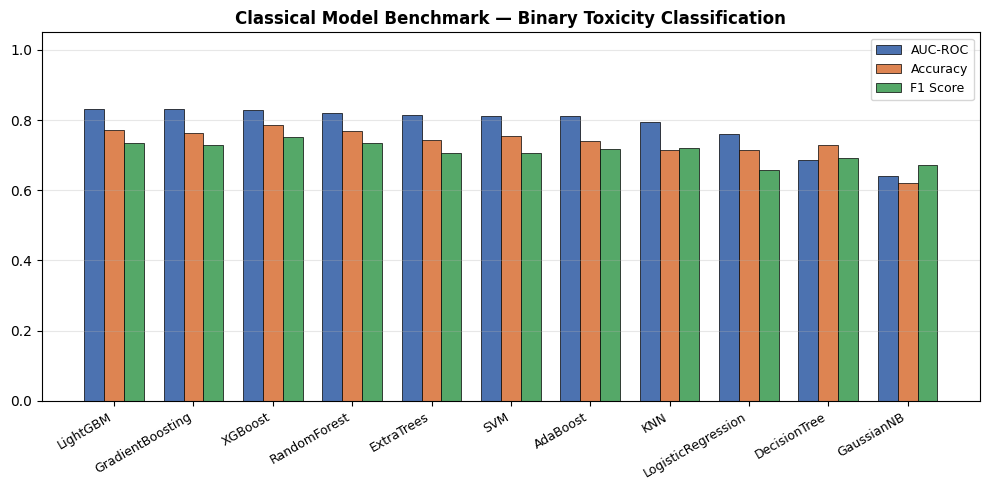

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(dfr)); w = 0.25
ax.bar(x-w, dfr['auc_roc'], w, label='AUC-ROC', color='#4C72B0', edgecolor='black', lw=0.5)
ax.bar(x, dfr['accuracy'], w, label='Accuracy', color='#DD8452', edgecolor='black', lw=0.5)
ax.bar(x+w, dfr['f1'], w, label='F1 Score', color='#55A868', edgecolor='black', lw=0.5)
ax.set_xticks(x); ax.set_xticklabels(dfr['model'], rotation=30, ha='right', fontsize=9)
ax.set_ylim(0, 1.05); ax.legend(fontsize=9); ax.grid(axis='y', alpha=0.3)
ax.set_title('Classical Model Benchmark — Binary Toxicity Classification', fontsize=12, fontweight='bold')
plt.tight_layout(); plt.savefig('figures/classical_benchmark.png', dpi=150, bbox_inches='tight'); plt.show()

In [ ]:
import seaborn as sns
from matplotlib.patches import Patch

# Feature importance for top 3 models — identify best descriptors

# Feature names: Morgan bits + RDKit descriptors (after variance filter)
morgan_names = [f'Morgan_{i}' for i in range(2048)]
all_feat_names = np.array(morgan_names + desc_names)
feat_names_filtered = all_feat_names[sel.get_support()]

top_n = 20
fig, axes = plt.subplots(1, 3, figsize=(18, 7))

for ax, model_name in zip(axes, top3):
    model_obj = models[model_name]
    if hasattr(model_obj, 'feature_importances_'):
        importances = model_obj.feature_importances_
    elif hasattr(model_obj, 'coef_'):
        importances = np.abs(model_obj.coef_[0])
    else:
        ax.set_title(f'{model_name}\n(no importance available)')
        continue

    indices = np.argsort(importances)[::-1][:top_n]
    top_names = feat_names_filtered[indices]
    top_vals = importances[indices]

    # Colour: RDKit descriptors vs Morgan fingerprints
    colors_bar = ['#DD8452' if not n.startswith('Morgan_') else '#4C72B0' for n in top_names]

    sns.barplot(x=top_vals[::-1], y=top_names[::-1], palette=colors_bar[::-1], ax=ax, orient='h')
    ax.set_title(f'{model_name} — Top {top_n} Features', fontsize=11, fontweight='bold')
    ax.set_xlabel('Importance', fontsize=9)
    ax.set_ylabel('')
    ax.grid(axis='x', linestyle='--', alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

# Legend
legend_els = [Patch(facecolor='#DD8452', label='RDKit Descriptor'),
              Patch(facecolor='#4C72B0', label='Morgan Fingerprint')]
fig.legend(handles=legend_els, loc='lower center', ncol=2, fontsize=10, frameon=False, bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Top Descriptor Contributions — Best 3 Classical Models', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
os.makedirs('figures', exist_ok=True)
plt.savefig('figures/feature_importance_top3.png', dpi=150, bbox_inches='tight')
plt.show()

# Summary: how many RDKit descriptors vs Morgan bits in top 20
print('\n=== Feature Type Breakdown (Top 20) ===')
for model_name in top3:
    model_obj = models[model_name]
    if not hasattr(model_obj, 'feature_importances_'):
        continue
    importances = model_obj.feature_importances_
    indices = np.argsort(importances)[::-1][:top_n]
    top_names = feat_names_filtered[indices]
    n_rdkit = sum(1 for n in top_names if not n.startswith('Morgan_'))
    n_morgan = top_n - n_rdkit
    print(f'  {model_name:20s}: {n_rdkit} RDKit descriptors, {n_morgan} Morgan bits')
    rdkit_tops = [n for n in top_names if not n.startswith('Morgan_')]
    print(f'    Top RDKit descriptors: {rdkit_tops}')